<a href="https://colab.research.google.com/github/ankitkparashar/python/blob/main/CSML/Module3/BikeSharingData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Download the Bike Sharing Demand test and train data
bike_df = pd.read_csv('train-2.csv')
bike_df_test = pd.read_csv('test.csv')

In [4]:
print(bike_df.shape)
print(bike_df_test.shape)

(10886, 12)
(6493, 9)


In [5]:
print(bike_df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [6]:
print(bike_df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB
None


In [7]:
bike_df['datetime'] = bike_df['datetime'].astype('datetime64[ns]')
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [8]:
bike_df["year"] = bike_df["datetime"].dt.year
bike_df["month"] = bike_df["datetime"].dt.month
bike_df["day"] = bike_df["datetime"].dt.day
bike_df["hour"] = bike_df["datetime"].dt.hour

bike_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [9]:
print(bike_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
dtypes: datetime64[ns](1), 

In [10]:
drop_columns = ['datetime', 'casual', 'registered']
bike_df = bike_df.drop(drop_columns, axis=1)
bike_df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,13,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,1,2011,1,1,4


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [14]:
# Root mean squared Log error
def rmsle(y, y_pred):
    log_y = np.log(y)
    log_y_pred = np.log(y_pred)
    squared_error = (log_y - log_y_pred) ** 2
    rmsle = np.sqrt(np.mean(squared_error))
    return rmsle

In [13]:
def rmse(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

In [15]:
def evaluate_regr(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    rmsle_value = rmsle(y, y_pred)
    rmse_value = rmse(y, y_pred)
    return mae, rmsle_value, rmse_value

2. Modelling

Let's use Regression first

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [17]:
y_target = bike_df['count']
X_features = bike_df.drop(columns=['count'])

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=1)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
y_pred = lr_reg.predict(X_test)
mae, rmsle_value, rmse_value = evaluate_regr(y_test, y_pred)
print('MAE:', mae)
print('RMSLE:', rmsle_value)
print('RMSE:', rmse_value)

MAE: 106.59243335029824
RMSLE: 1.2014416054883486
RMSE: 142.65438623522502


In [18]:
bike_df['count'].describe()

,count
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
25%,42.000000
50%,145.000000
75%,284.000000
max,977.000000


In [19]:
def get_top_error_data(y_test, y_pred, n_top=5):
    result_df = pd.DataFrame(data={'y_test': y_test, 'y_pred': np.round(y_pred)})
    result_df['diff'] = np.abs(result_df['y_test'] - result_df['y_pred'])
    result_df = result_df.sort_values(by='diff', ascending=False)[:n_top]
    print(result_df)


In [20]:
get_top_error_data(y_test, y_pred)

      y_test  y_pred   diff
9575     809   191.0  618.0
9752     948   360.0  588.0
9584     917   336.0  581.0
9320     970   410.0  560.0
9767     798   241.0  557.0


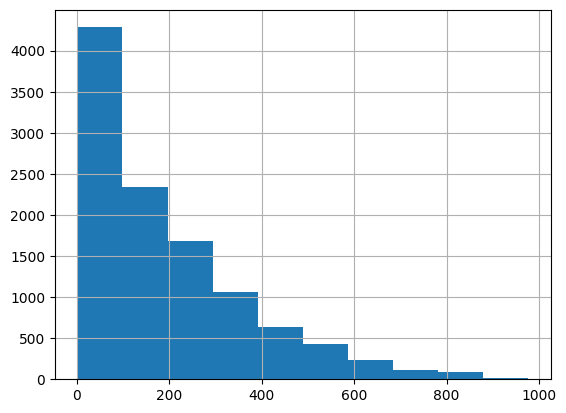

In [21]:
y_target.hist()
plt.show()